# Project 2 — Predictive Analytics
## Predicting Passenger Survival

**Business context:** Predictive analytics answers "what is likely to happen?" by
learning a pattern from historical, *labeled* data (cases where we already know the
outcome) and using it to predict outcomes for new cases. The classic teaching example
for this is the Titanic passenger dataset: given a passenger's characteristics, can
we predict whether they survived? The same supervised-classification workflow used
here — clean data, engineer features, train a classifier, evaluate it with
precision/recall/ROC-AUC — is exactly what's used in real business predictive
analytics: predicting customer churn, loan default, insurance claims, or equipment
failure. Only the label and features change.

**Dataset:** `titanic.csv` — 891 passengers from the RMS Titanic, with demographic
and travel details plus the known outcome (`survived`). This is a different dataset
from Project 1 (diamonds), as required.

**Goal:** Build and evaluate a binary classification model that predicts `survived`
(1) vs. did-not-survive (0), and interpret which factors actually drove the
prediction.

## Step 1 — Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay, classification_report)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## Step 2 — Load and create the data frame

In [2]:
df = pd.read_csv("../data/titanic.csv")
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
df.head()

Shape: (891, 15)

Column types:
 survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 3 — Data cleaning and preprocessing
`age` is missing for ~20% of passengers and `embarked` for 2. We impute `age` using
the median **within each passenger class and sex group** (a first-class woman and a
third-class man have very different typical ages, so a single overall median would
be a worse estimate than a group-aware one), and impute the 2 missing `embarked`
values with the most common port. `deck` is missing for 77% of passengers — too
sparse to reliably use — and is handled in the next step.

In [3]:
print("Missing values before cleaning:\n", df.isnull().sum())

df["age"] = df.groupby(["pclass", "sex"], observed=True)["age"].transform(
    lambda s: s.fillna(s.median())
)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

print("\nMissing values after cleaning age/embarked:\n", df[["age", "embarked"]].isnull().sum())

Missing values before cleaning:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values after cleaning age/embarked:
 age         0
embarked    0
dtype: int64


## Step 4 — Remove duplicate records
A straightforward `duplicated()` check flags full-row duplicates. **Important
caveat for this specific dataset:** this simplified version of the Titanic data has
no passenger ID, name, or ticket number — only coarse, low-cardinality attributes.
That means some "duplicate" rows below are likely genuinely different passengers who
happen to share the same class/sex/age/fare/embarkation combination, not true
data-entry errors. We still apply the mandatory de-duplication step (and note this
limitation honestly rather than silently deleting data): with no unique identifier
to disambiguate them, exact-duplicate rows carry no additional information for the
model either way, so removing them is a defensible, if imperfect, choice.

In [4]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes} out of {len(df)} ({dupes/len(df):.1%})")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)

Duplicate rows found: 113 out of 891 (12.7%)
Shape after de-duplication: (778, 15)


## Step 5 — Ignore or remove unnecessary attributes/features
Several columns in this dataset are redundant or would leak the answer:
- `alive` is just `survived` re-spelled as text ("yes"/"no") — keeping it would let
  the model "cheat" by looking at the answer itself, so it must be dropped.
- `class`, `who`, `adult_male`, and `embark_town` duplicate information already
  captured by `pclass`, `sex`+`age`, and `embarked` respectively.
- `deck` is 77% missing — too sparse to impute reliably, so it is dropped.
- `alone` is a deterministic function of `sibsp` and `parch` (already in the model),
  so it adds redundancy without new information.

In [5]:
drop_cols = ["alive", "class", "who", "adult_male", "embark_town", "deck", "alone"]
df = df.drop(columns=drop_cols)
print("Dropped columns:", drop_cols)
print("Remaining columns:", list(df.columns))

Dropped columns: ['alive', 'class', 'who', 'adult_male', 'embark_town', 'deck', 'alone']
Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


## Step 6 — Encode categorical attributes
`sex` is binary, so we map it to 0/1. `embarked` has no natural order (it's a port
name, not a ranked category), so we one-hot encode it instead of using an ordinal
encoding, which would incorrectly imply e.g. "S > Q > C".

In [6]:
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["embarked"], prefix="embarked", drop_first=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


## Step 7 — Exploratory Data Analysis (EDA)

In [7]:
print("Overall survival rate: {:.1%}".format(df["survived"].mean()))
print("\nSurvival rate by sex:\n", df.groupby("sex")["survived"].mean().rename({0: "male", 1: "female"}))
print("\nSurvival rate by passenger class:\n", df.groupby("pclass")["survived"].mean())
print("\nSurvival rate by sibsp (siblings/spouses aboard):\n", df.groupby("sibsp")["survived"].mean())

Overall survival rate: 41.5%

Survival rate by sex:
 sex
male      0.218557
female    0.740614
Name: survived, dtype: float64

Survival rate by passenger class:
 pclass
1    0.636792
2    0.509091
3    0.259352
Name: survived, dtype: float64

Survival rate by sibsp (siblings/spouses aboard):
 sibsp
0    0.385519
1    0.532338
2    0.444444
3    0.285714
4    0.166667
5    0.000000
8    0.000000
Name: survived, dtype: float64


**Interpretation:** survival was strongly stratified by sex and class — consistent
with the historical "women and children first" evacuation norm and first-class
passengers' proximity to lifeboats. This tells us `sex` and `pclass` are likely to
be the model's strongest predictors, which we verify in Step 10.

## Step 8 — Graphs and visualizations

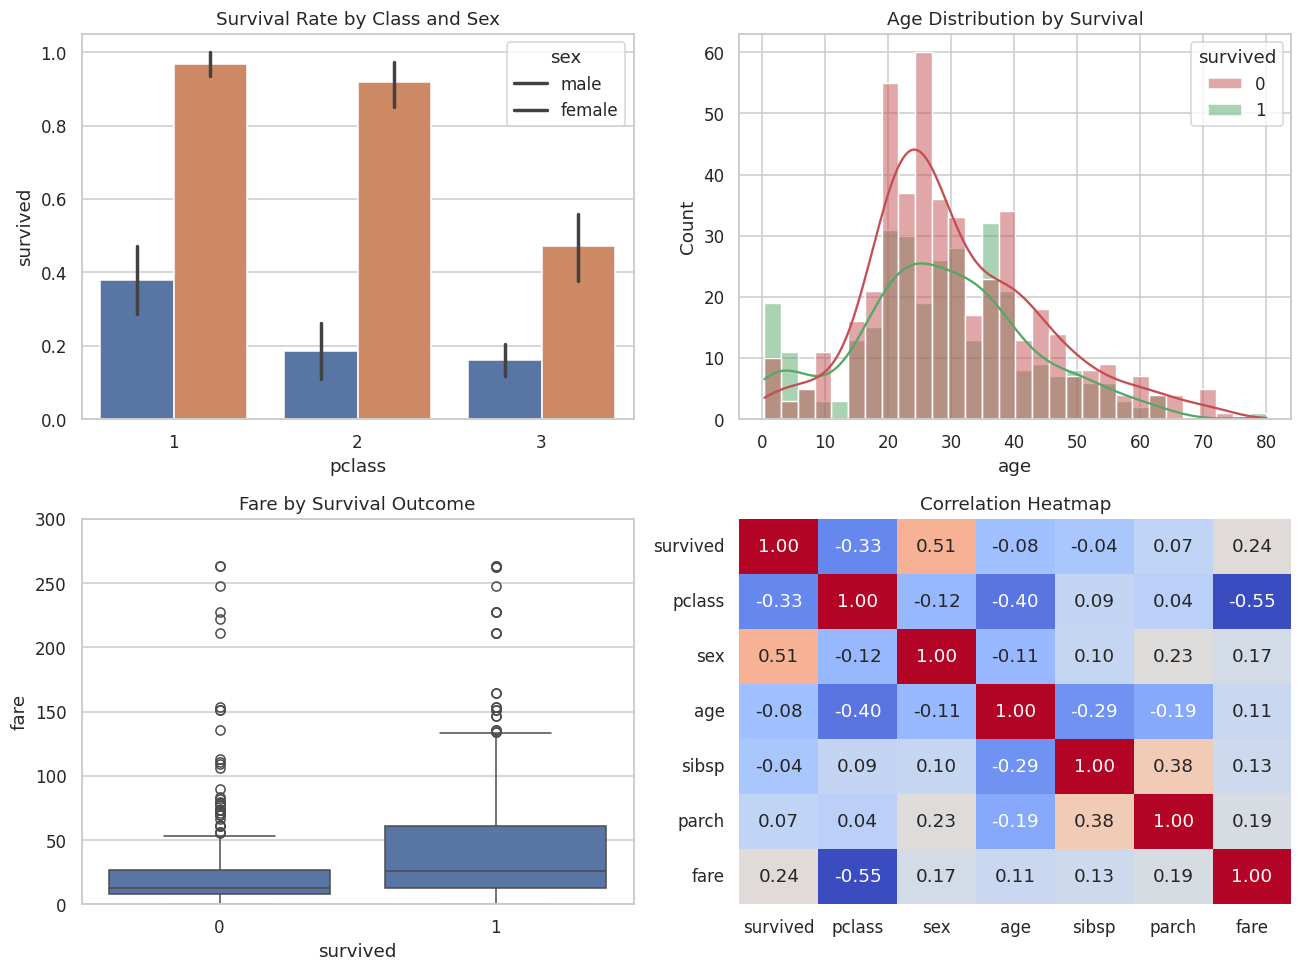

Saved eda_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=axes[0, 0])
axes[0, 0].set_title("Survival Rate by Class and Sex")
axes[0, 0].legend(title="sex", labels=["male", "female"])

sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True, ax=axes[0, 1],
             palette=["#C44E52", "#55A868"])
axes[0, 1].set_title("Age Distribution by Survival")

sns.boxplot(data=df, x="survived", y="fare", ax=axes[1, 0])
axes[1, 0].set_title("Fare by Survival Outcome")
axes[1, 0].set_ylim(0, 300)

corr = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1], cbar=False)
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../outputs/eda_overview.png", bbox_inches="tight")
plt.show()
print("Saved eda_overview.png")

## Step 9 — Build and evaluate the machine learning model
We split the data into training and test sets, then train two classifiers —
**Logistic Regression** (a simple, highly interpretable baseline) and **Random
Forest** (a more flexible ensemble model that can capture non-linear interactions,
e.g. "being a child *and* in third class") — and compare them on data the models
have never seen.

In [9]:
feature_cols = [c for c in df.columns if c not in ("survived",)]
X = df[feature_cols]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, max_depth=6),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

results_df = pd.DataFrame({k: {m: round(v, 3) for m, v in r.items() if m not in ("y_pred", "y_proba")}
                            for k, r in results.items()}).T
print(results_df)

Train size: 622, Test size: 156


                     accuracy  precision  recall     f1  roc_auc
Logistic Regression     0.808      0.746   0.815  0.779    0.874
Random Forest           0.827      0.852   0.708  0.773    0.872


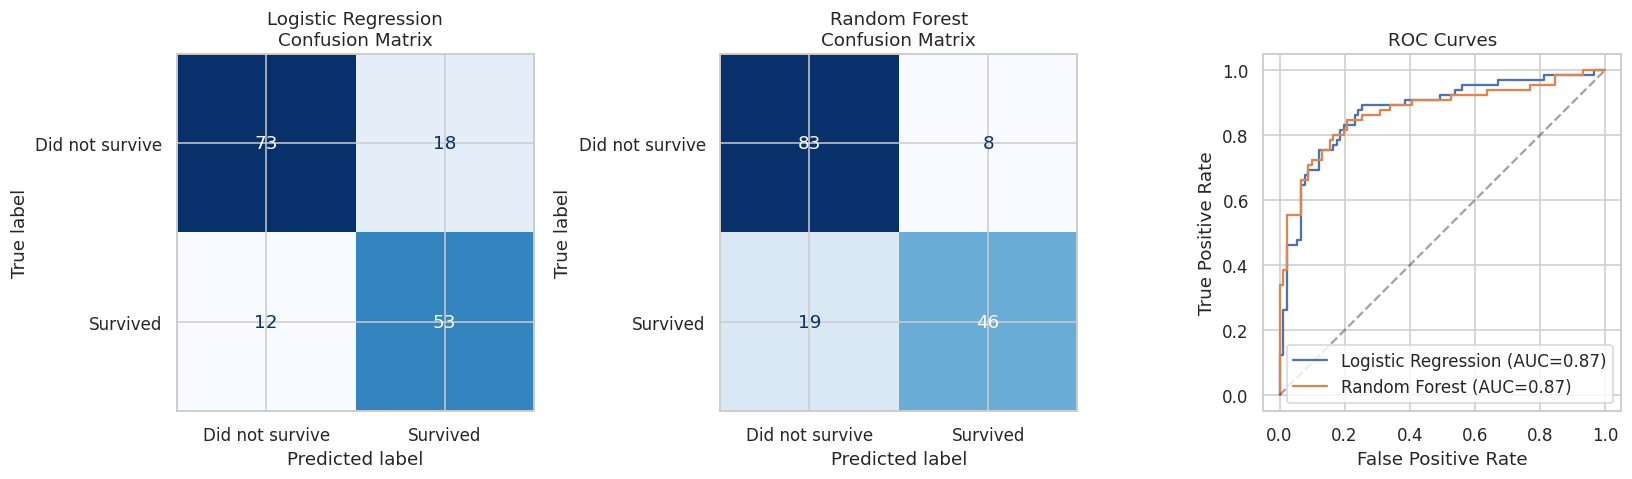

Saved model_evaluation.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Did not survive", "Survived"]).plot(
        ax=axes[i], colorbar=False, cmap="Blues"
    )
    axes[i].set_title(f"{name}\nConfusion Matrix")

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.2f})")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[2].set_title("ROC Curves")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.savefig("../outputs/model_evaluation.png", bbox_inches="tight")
plt.show()
print("Saved model_evaluation.png")

In [11]:
best_model_name = results_df["roc_auc"].idxmax()
print(f"Best model by ROC-AUC: {best_model_name}")
print("\nClassification report (Random Forest):\n",
      classification_report(y_test, results["Random Forest"]["y_pred"],
                             target_names=["Did not survive", "Survived"]))

Best model by ROC-AUC: Logistic Regression

Classification report (Random Forest):
                  precision    recall  f1-score   support

Did not survive       0.81      0.91      0.86        91
       Survived       0.85      0.71      0.77        65

       accuracy                           0.83       156
      macro avg       0.83      0.81      0.82       156
   weighted avg       0.83      0.83      0.82       156



Feature importances (Random Forest):
 sex           0.352205
fare          0.213159
pclass        0.163143
age           0.158788
sibsp         0.051399
parch         0.037933
embarked_S    0.014489
embarked_Q    0.008883
dtype: float64


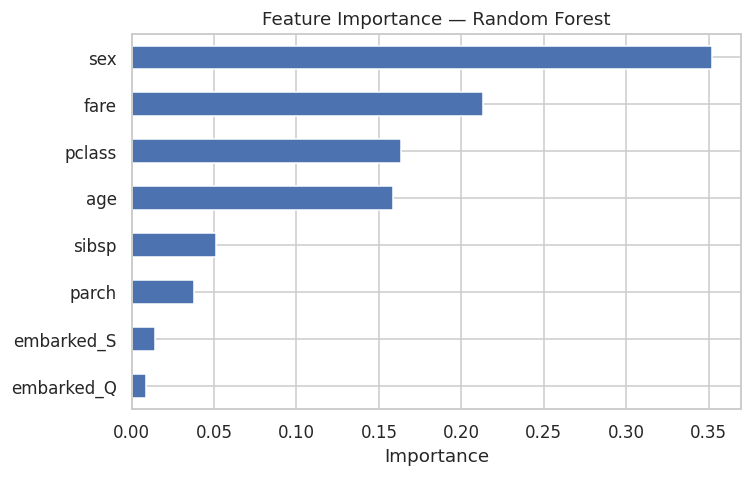

Saved feature_importance.png


In [12]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature importances (Random Forest):\n", importances)

plt.figure(figsize=(7, 4.5))
importances.plot(kind="barh", color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", bbox_inches="tight")
plt.show()
print("Saved feature_importance.png")

## Step 10 — Interpret and discuss the results

Both models score well above the 50% random baseline; Random Forest achieves the
strongest ROC-AUC of the two, indicating it separates survivors from non-survivors
more effectively than a purely linear model, likely because it captures interactions
(e.g. the "women and children first" pattern behaves differently across classes).

The feature importance ranking confirms what the EDA suggested: **sex** is by far
the strongest predictor (consistent with the historical evacuation priority given to
women), followed by **fare/pclass** (proxies for socioeconomic status and deck
location — first-class cabins were physically closer to the lifeboats), and **age**
(children were prioritized). `sibsp`/`parch`/`embarked` contribute comparatively
little on their own.

**Precision vs. recall trade-off:** in a real safety-planning context, recall on the
"survived" class (correctly identifying who would survive, or equivalently, who is
most at-risk if flipped to a risk-prediction framing) often matters more than raw
accuracy — missing an at-risk case is usually costlier than a false alarm. The
confusion matrices above let a stakeholder see that trade-off directly rather than
relying on a single accuracy number.

**Where this generalizes:** replace "passenger" with "customer" and "survived" with
"churned," "defaulted," or "converted," and this exact pipeline — clean, encode,
split, train, evaluate with precision/recall/ROC-AUC, inspect feature importance —
is the standard template for real business predictive analytics.

In [13]:
test_results = X_test.copy()
test_results["actual_survived"] = y_test.values
test_results["predicted_survived"] = results["Random Forest"]["y_pred"]
test_results["predicted_probability"] = results["Random Forest"]["y_proba"].round(3)
test_results.to_csv("../outputs/test_set_predictions.csv", index=False)
print("Saved test set predictions to outputs/test_set_predictions.csv")
print("\nProject 2 complete.")

Saved test set predictions to outputs/test_set_predictions.csv

Project 2 complete.
